Training Score Model...
Step 0, Loss: 1.1261
Step 500, Loss: 0.0173
Step 1000, Loss: 0.0104
Step 1500, Loss: 0.0046
Step 2000, Loss: 0.0025
Step 2500, Loss: 0.0103
Sampling via Reverse SDE...


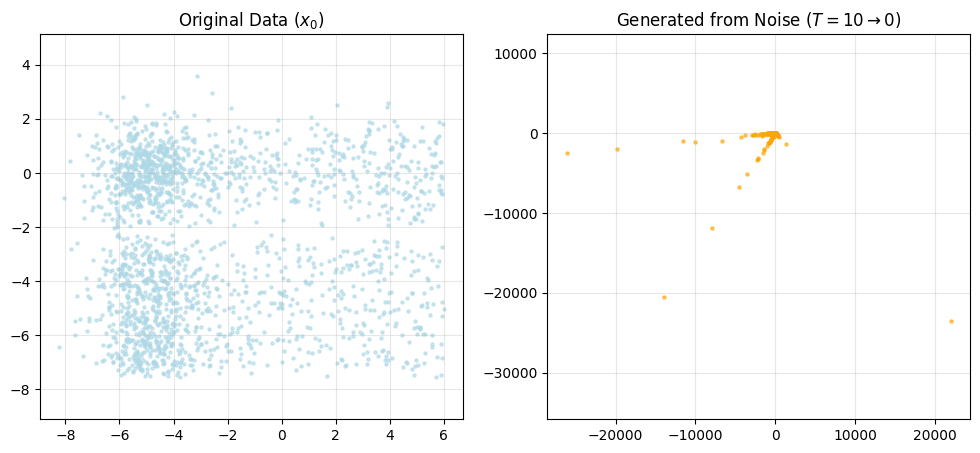

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. 數據生成：你定義的 Blob + Line
def sample_line(n_points):
    slope, intercept = 0.4, -5.0
    x = np.random.uniform(-6, 6, size=n_points)
    y = slope * x + intercept + np.random.randn(n_points) * 0.2
    return np.stack([x, y], axis=1)

def sample_blob(n_points):
    mu, C = np.array([-5, 0]), np.eye(2) * 1.0
    return mu + np.random.multivariate_normal([0,0], C, size=n_points)

def sample_p0_mix(n_samples=256):
    n_blob, n_line = n_samples // 2, n_samples // 2
    data = np.concatenate([sample_blob(n_blob), sample_line(n_line)], axis=0)
    np.random.shuffle(data)
    return torch.tensor(data, dtype=torch.float32)

# 2. 定義 Score 網路 (預測雜訊方向)
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128), nn.Softplus(),
            nn.Linear(128, 128), nn.Softplus(),
            nn.Linear(128, 2)
        )
    def forward(self, x, t):
        t_stack = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_stack], dim=-1))

# 3. 超參數設定
beta, sigma, T = 10.0, 5.0, 10.0
model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4. 訓練階段 (學習去噪)
print("Training Score Model...")
for step in range(2501):
    x0 = sample_p0_mix(128)
    t = torch.rand(x0.shape[0]) * T
    
    # 正向加噪 (OU Process 解析解)
    mu_t = torch.exp(-beta * t).view(-1, 1) * x0
    std_t = torch.sqrt((sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t))).view(-1, 1)
    
    eps = torch.randn_like(x0)
    xt = mu_t + std_t * eps
    
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(xt, t), eps) # 學習預測加入的雜訊 eps
    loss.backward()
    optimizer.step()
    if step % 500 == 0: print(f"Step {step}, Loss: {loss.item():.4f}")

# 5. 逆向採樣 (從 T=10 走回 T=0)
print("Sampling via Reverse SDE...")
n_gen = 2000
x_t = torch.randn(n_gen, 2) * np.sqrt(sigma**2 / (2 * beta)) # 從穩態分佈開始
"""
dt = 0.01

for i in range(int(T/dt)):
    t_val = T - i * dt
    t_tensor = torch.full((n_gen,), t_val)
    
    with torch.no_grad():
        eps_pred = model(x_t, t_tensor)
    
    # 逆向更新步 (Reverse Euler-Maruyama)
    std_t_val = np.sqrt((sigma**2 / (2*beta)) * (1 - np.exp(-2*beta*t_val)))
    score = -eps_pred / (std_t_val + 1e-6)
    
    # dx = [f - g^2 * score] dt + g * dW
    drift = -beta * x_t
    reverse_drift = drift - (sigma**2) * score
    x_t = x_t - reverse_drift * dt + sigma * np.sqrt(dt) * torch.randn_like(x_t)
"""
eta = T / n_gen  # 你的論文中提到的步長
for i in range(n_gen):
    t_val = T - i * eta
    t_tensor = torch.full((n_gen,), t_val)
    
    with torch.no_grad():
        eps_pred = model(x_t, t_tensor)
    
    # 逆向更新步 (Reverse Euler-Maruyama)
    std_t_val = np.sqrt((sigma**2 / (2*beta)) * (1 - np.exp(-2*beta*t_val)))
    score = -eps_pred / (std_t_val + 1e-6)
    
    # dx = [f - g^2 * score] dt + g * dW
    drift = -beta * x_t
    reverse_drift = drift - (sigma**2) * score
    x_t = x_t - reverse_drift * eta + sigma * np.sqrt(eta) * torch.randn_like(x_t)


# 6. 繪圖
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.scatter(sample_p0_mix(2000)[:,0], sample_p0_mix(2000)[:,1], color='lightblue', s=5, alpha=0.6)
plt.title("Original Data ($x_0$)"); plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2); plt.scatter(x_t[:, 0], x_t[:, 1], color='orange', s=5, alpha=0.6)
plt.title("Generated from Noise ($T=10 \\to 0$)"); plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.show()